# Point Source Refractor — NK=1600 Fast Benchmark

Loads `results_refraction_NK1600.npz` (produced by `python generate_results_refraction.py`).

| | |
|---|---|
| **Benchmark** | spherical‑patch refraction (Figure 4) |
| **Cost** | $c(x,y) = -\log(1 - \kappa\,(x\cdot y))$, $\kappa=0.6$ |
| **Algorithm** | Sinkhorn divergence, cold‑start |
| **Grid** | NK=1600 Halton QMC on upper hemisphere |
| **Source** | $\theta\in[\pi/12,\,\pi/3]$, $\phi\in[\pi/12,\,\pi/4]$ |
| **Target** | $\theta\in[\pi/10,\,\pi/5]$, $\phi\in[\pi/10,\,\pi/5]$ |

In [66]:
import os, sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

matplotlib.rcParams.update({'font.size': 11})

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from reflector.distributions import stereo_north

# ── Load ───────────────────────────────────────────────────────────────
data = np.load(os.path.join('..', 'results', 'results_refraction_NK1600.npz'))

x      = data['x'];        y      = data['y']       # (1600, 3) clouds
p      = data['p'];        q      = data['q']       # normalised densities
f_raw  = data['f_raw'];    g_raw  = data['g_raw']   # Sinkhorn potentials (pre-subtraction)
f_id   = data['f_id'];     g_id   = data['g_id']    # identity biases
f      = data['f'];        g      = data['g']       # corrected = f_raw - f_id
R      = data['R'];        Ref    = data['Ref']     # refractor radii / surface
gc     = data['gc'];       fc     = data['fc']      # c-transforms
Refc   = data['Refc']

X_MeshGrid = data['X_MeshGrid']             # (256, 256) source density image
Y_MeshGrid = data['Y_MeshGrid']             # (256, 256) target density image
grid_side  = data['grid_side']              # axis  linspace(-0.6, 0.6, 256)

Y_projected        = data['Y_projected']        # (K, 3) target support  (u,v,q)
Y_Pushed_projected = data['Y_Pushed_projected'] # (M, 3) push-forward    (u,v,q)
y_push_3d          = data['y_push_3d']          # (M, 3) 3D upper-hemisphere pushed pts

kappa  = float(data['kappa'])                   # refraction index κ

NK     = len(x)
mask_p = p > 0
mask_q = q > 0
# Both patches are on the UPPER hemisphere → north-pole projection for both
u_x, v_x = stereo_north(x)
u_y, v_y = stereo_north(y)

print(f'NK={NK},  κ={kappa},  source support={mask_p.sum()},  target support={mask_q.sum()}')
print(f'R (all NK):    min={R.min():.4f}, max={R.max():.4f}')
print(f'R (supported): min={R[mask_p].min():.4f}, max={R[mask_p].max():.4f}, mean={R[mask_p].mean():.4f}')

NK=1600,  κ=0.6,  source support=1067,  target support=833
R (all NK):    min=0.9719, max=1.4625
R (supported): min=0.9719, max=1.1362, mean=1.0666


## 1 — Source & Target Distributions (2D stereographic projections)

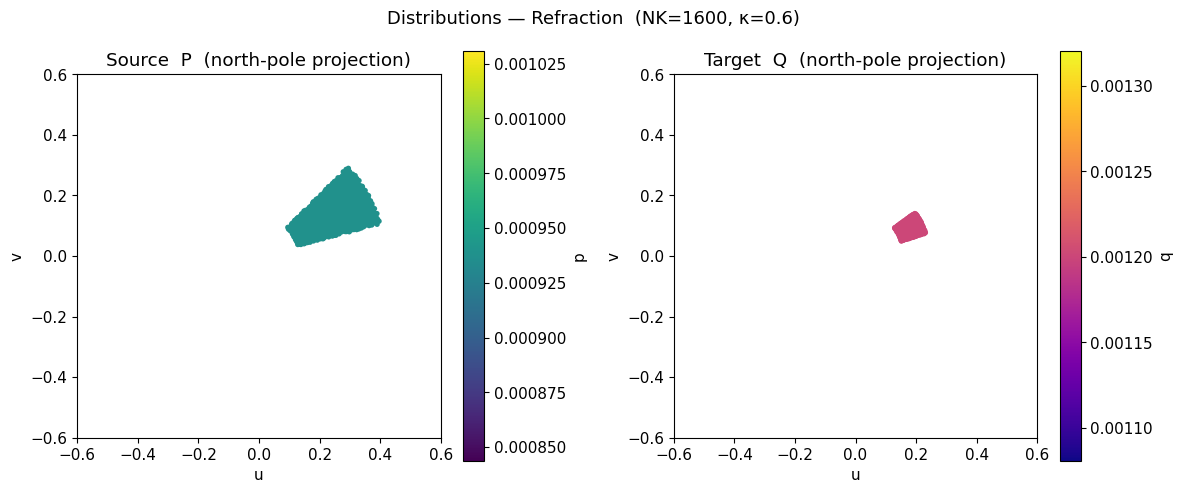

Saved fig_distributions.png


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc0 = axes[0].scatter(u_x[mask_p], v_x[mask_p], c=p[mask_p],
                       cmap='viridis', s=15, edgecolors='none')
plt.colorbar(sc0, ax=axes[0], label='p')
axes[0].set_title('Source  P  (north-pole projection)')
axes[0].set_xlabel('u');  axes[0].set_ylabel('v')
axes[0].set_aspect('equal');  axes[0].set_xlim(-0.6, 0.6);  axes[0].set_ylim(-0.6, 0.6)

sc1 = axes[1].scatter(u_y[mask_q], v_y[mask_q], c=q[mask_q],
                       cmap='plasma', s=15, edgecolors='none')
plt.colorbar(sc1, ax=axes[1], label='q')
axes[1].set_title('Target  Q  (north-pole projection)')
axes[1].set_xlabel('u');  axes[1].set_ylabel('v')
axes[1].set_aspect('equal');  axes[1].set_xlim(-0.6, 0.6);  axes[1].set_ylim(-0.6, 0.6)

plt.suptitle(f'Distributions — Refraction  (NK={NK}, κ={kappa})', fontsize=13)
plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_distributions.png')

## 2 — Refractor Surface (3D scatter)

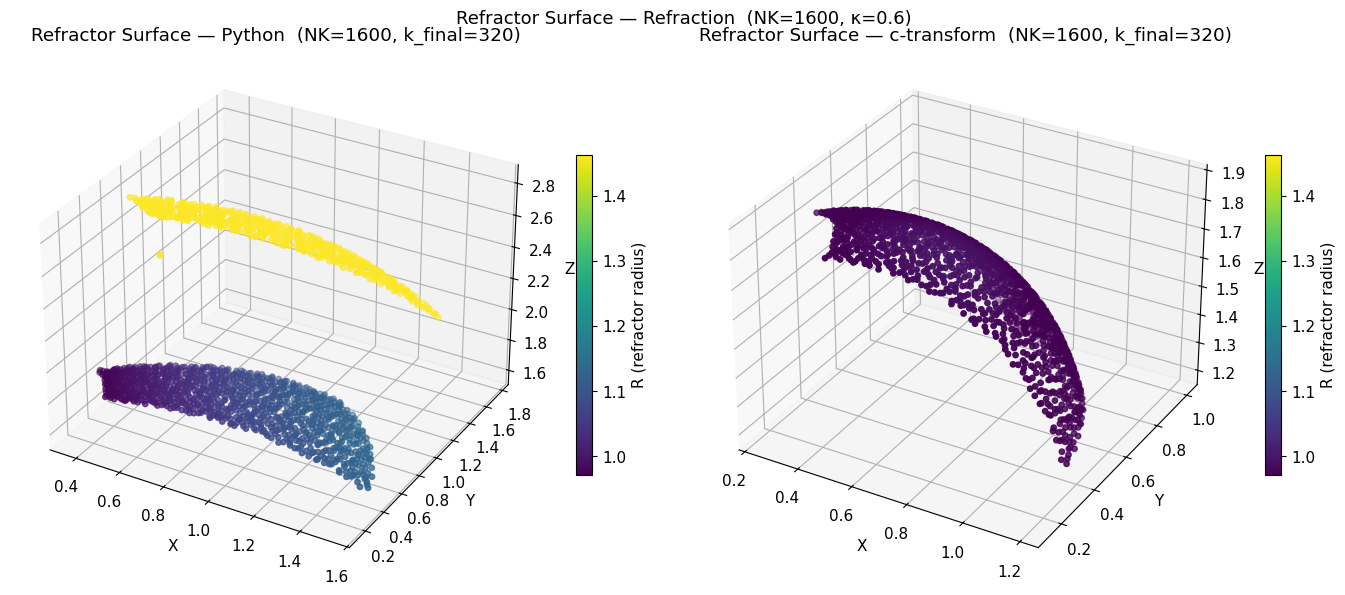

Saved fig_refractor_3d.png


In [68]:
vmin = R.min()   # full R range (all NK) for colour scale
vmax = R.max()
k_final = 8 * int(np.floor(np.sqrt(NK)))

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(Ref[:, 0], Ref[:, 1], Ref[:, 2],
                  c=R, cmap='viridis', s=15,
                  vmin=vmin, vmax=vmax, depthshade=True)
plt.colorbar(sc1, ax=ax1, label='R (refractor radius)', shrink=0.6)
ax1.set_title(f'Refractor Surface — Python  (NK={NK}, k_final={k_final})')
ax1.set_xlabel('X');  ax1.set_ylabel('Y');  ax1.set_zlabel('Z')

ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(Refc[:, 0], Refc[:, 1], Refc[:, 2],
                  c=np.exp(gc), cmap='viridis', s=15,
                  vmin=vmin, vmax=vmax, depthshade=True)
plt.colorbar(sc2, ax=ax2, label='R (refractor radius)', shrink=0.6)
ax2.set_title(f'Refractor Surface — c-transform  (NK={NK}, k_final={k_final})')
ax2.set_xlabel('X');  ax2.set_ylabel('Y');  ax2.set_zlabel('Z')

fig.suptitle(f'Refractor Surface — Refraction  (NK={NK}, κ={kappa})', fontsize=13)
plt.tight_layout()
plt.savefig('fig_refractor_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved fig_refractor_3d.png')

## 3 — Kantorovich Potentials (2D projections)

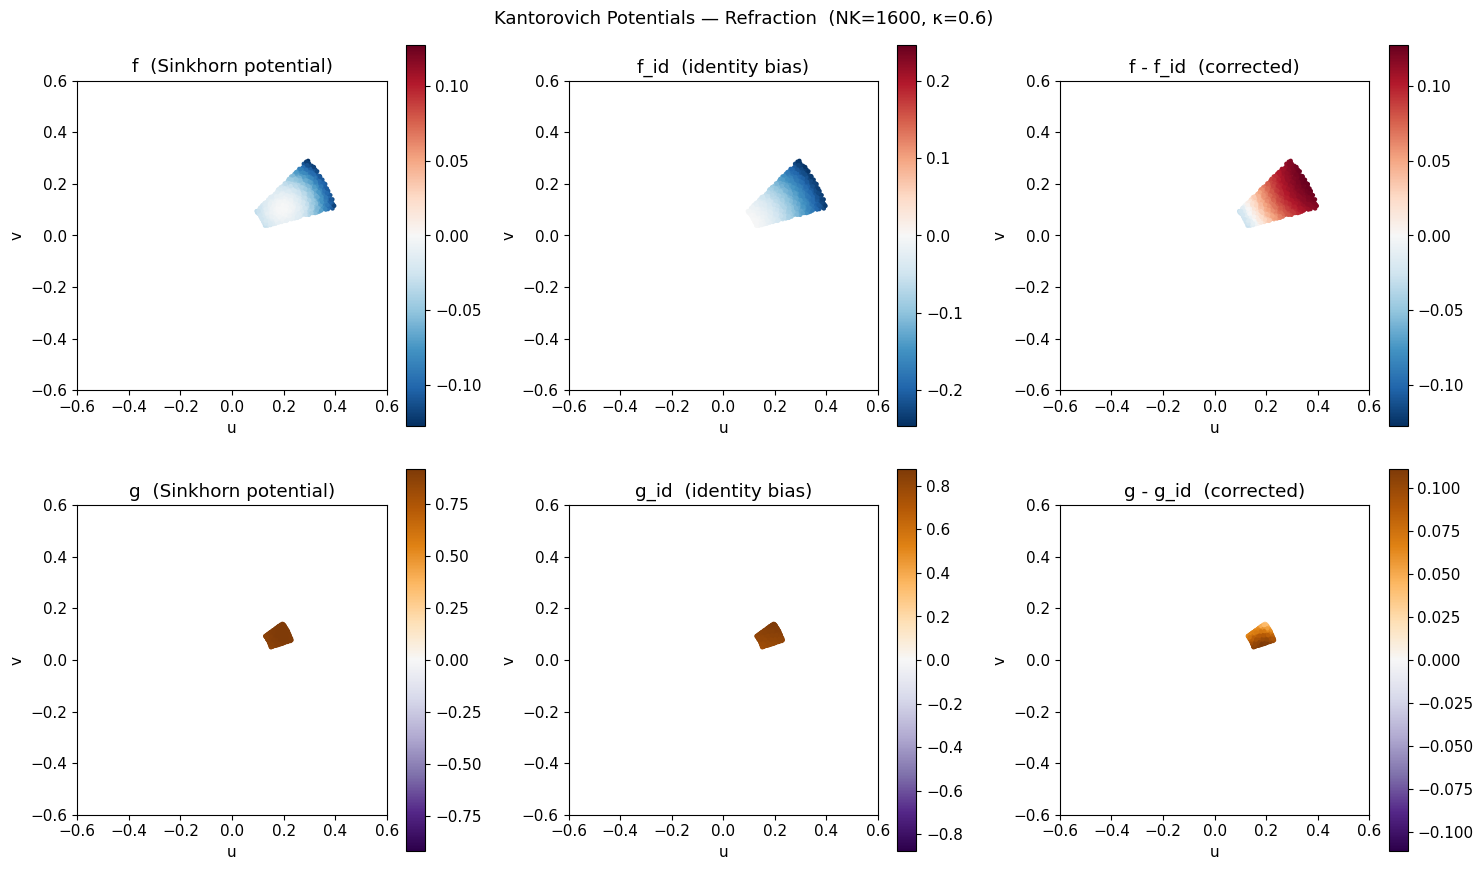

Saved fig_potentials.png


In [69]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

src_panels = [
    (f_raw,          'f  (Sinkhorn potential)',    'RdBu_r'),
    (f_id,           'f_id  (identity bias)',      'RdBu_r'),
    (f_raw - f_id,   'f - f_id  (corrected)',      'RdBu_r'),
]
for col, (arr, title, cmap) in enumerate(src_panels):
    ax   = axes[0, col]
    vals = arr[mask_p]
    lim  = np.abs(vals).max()
    sc   = ax.scatter(u_x[mask_p], v_x[mask_p], c=vals,
                      cmap=cmap, s=10, vmin=-lim, vmax=lim, edgecolors='none')
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('u');  ax.set_ylabel('v')
    ax.set_aspect('equal');  ax.set_xlim(-0.6, 0.6);  ax.set_ylim(-0.6, 0.6)

tgt_panels = [
    (g_raw,          'g  (Sinkhorn potential)',    'PuOr_r'),
    (g_id,           'g_id  (identity bias)',      'PuOr_r'),
    (g_raw - g_id,   'g - g_id  (corrected)',      'PuOr_r'),
]
for col, (arr, title, cmap) in enumerate(tgt_panels):
    ax   = axes[1, col]
    vals = arr[mask_q]
    lim  = np.abs(vals).max()
    sc   = ax.scatter(u_y[mask_q], v_y[mask_q], c=vals,
                      cmap=cmap, s=10, vmin=-lim, vmax=lim, edgecolors='none')
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('u');  ax.set_ylabel('v')
    ax.set_aspect('equal');  ax.set_xlim(-0.6, 0.6);  ax.set_ylim(-0.6, 0.6)

plt.suptitle(f'Kantorovich Potentials — Refraction  (NK={NK}, κ={kappa})', fontsize=13)
plt.tight_layout()
plt.savefig('fig_potentials.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_potentials.png')

## 4 — C-Transform Residuals
At convergence $f = g^c$ and $g = f^c$.  Residuals below show how close we are.

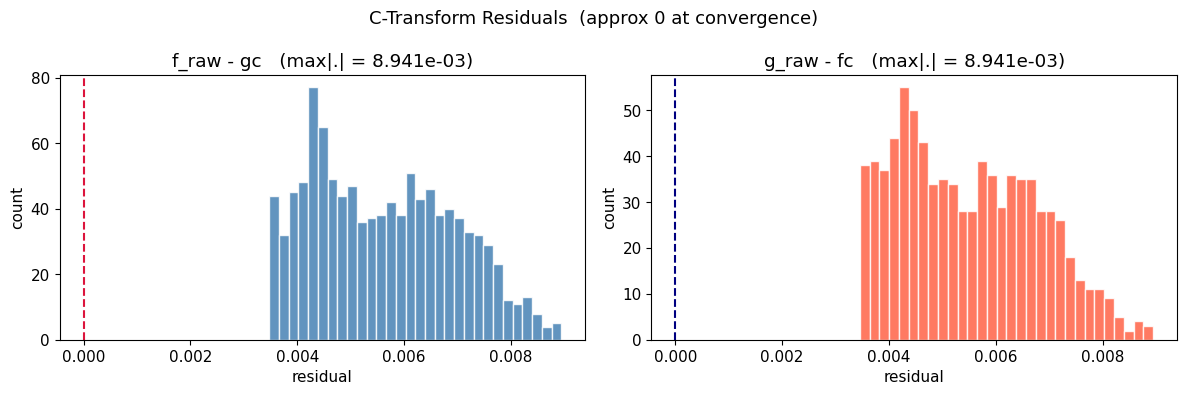

max|f_raw-gc| = 8.9409e-03
max|g_raw-fc| = 8.9409e-03
Saved fig_ctransform_residuals.png


In [70]:
# C-transform residuals check OT convergence:
#   gc[i] = min_{j: q[j]>0}(C(xi,yj) - g_raw[j]) should ≈ f_raw[i] at convergence
#   fc[j] = min_{i: p[i]>0}(C(xi,yj) - f_raw[i]) should ≈ g_raw[j] at convergence
res_fgc = f_raw[mask_p] - gc[mask_p]
res_gfc = g_raw[mask_q] - fc[mask_q]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(res_fgc, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='crimson', linewidth=1.5, linestyle='--')
axes[0].set_title(f'f_raw - gc   (max|.| = {np.abs(res_fgc).max():.3e})')
axes[0].set_xlabel('residual');  axes[0].set_ylabel('count')

axes[1].hist(res_gfc, bins=30, color='tomato', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='navy', linewidth=1.5, linestyle='--')
axes[1].set_title(f'g_raw - fc   (max|.| = {np.abs(res_gfc).max():.3e})')
axes[1].set_xlabel('residual');  axes[1].set_ylabel('count')

plt.suptitle('C-Transform Residuals  (approx 0 at convergence)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_ctransform_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'max|f_raw-gc| = {np.abs(res_fgc).max():.4e}')
print(f'max|g_raw-fc| = {np.abs(res_gfc).max():.4e}')
print('Saved fig_ctransform_residuals.png')

## 5 — Six-panel overview
Source density · target density · target scatter · pushed scatter · refractor 3D · overlay

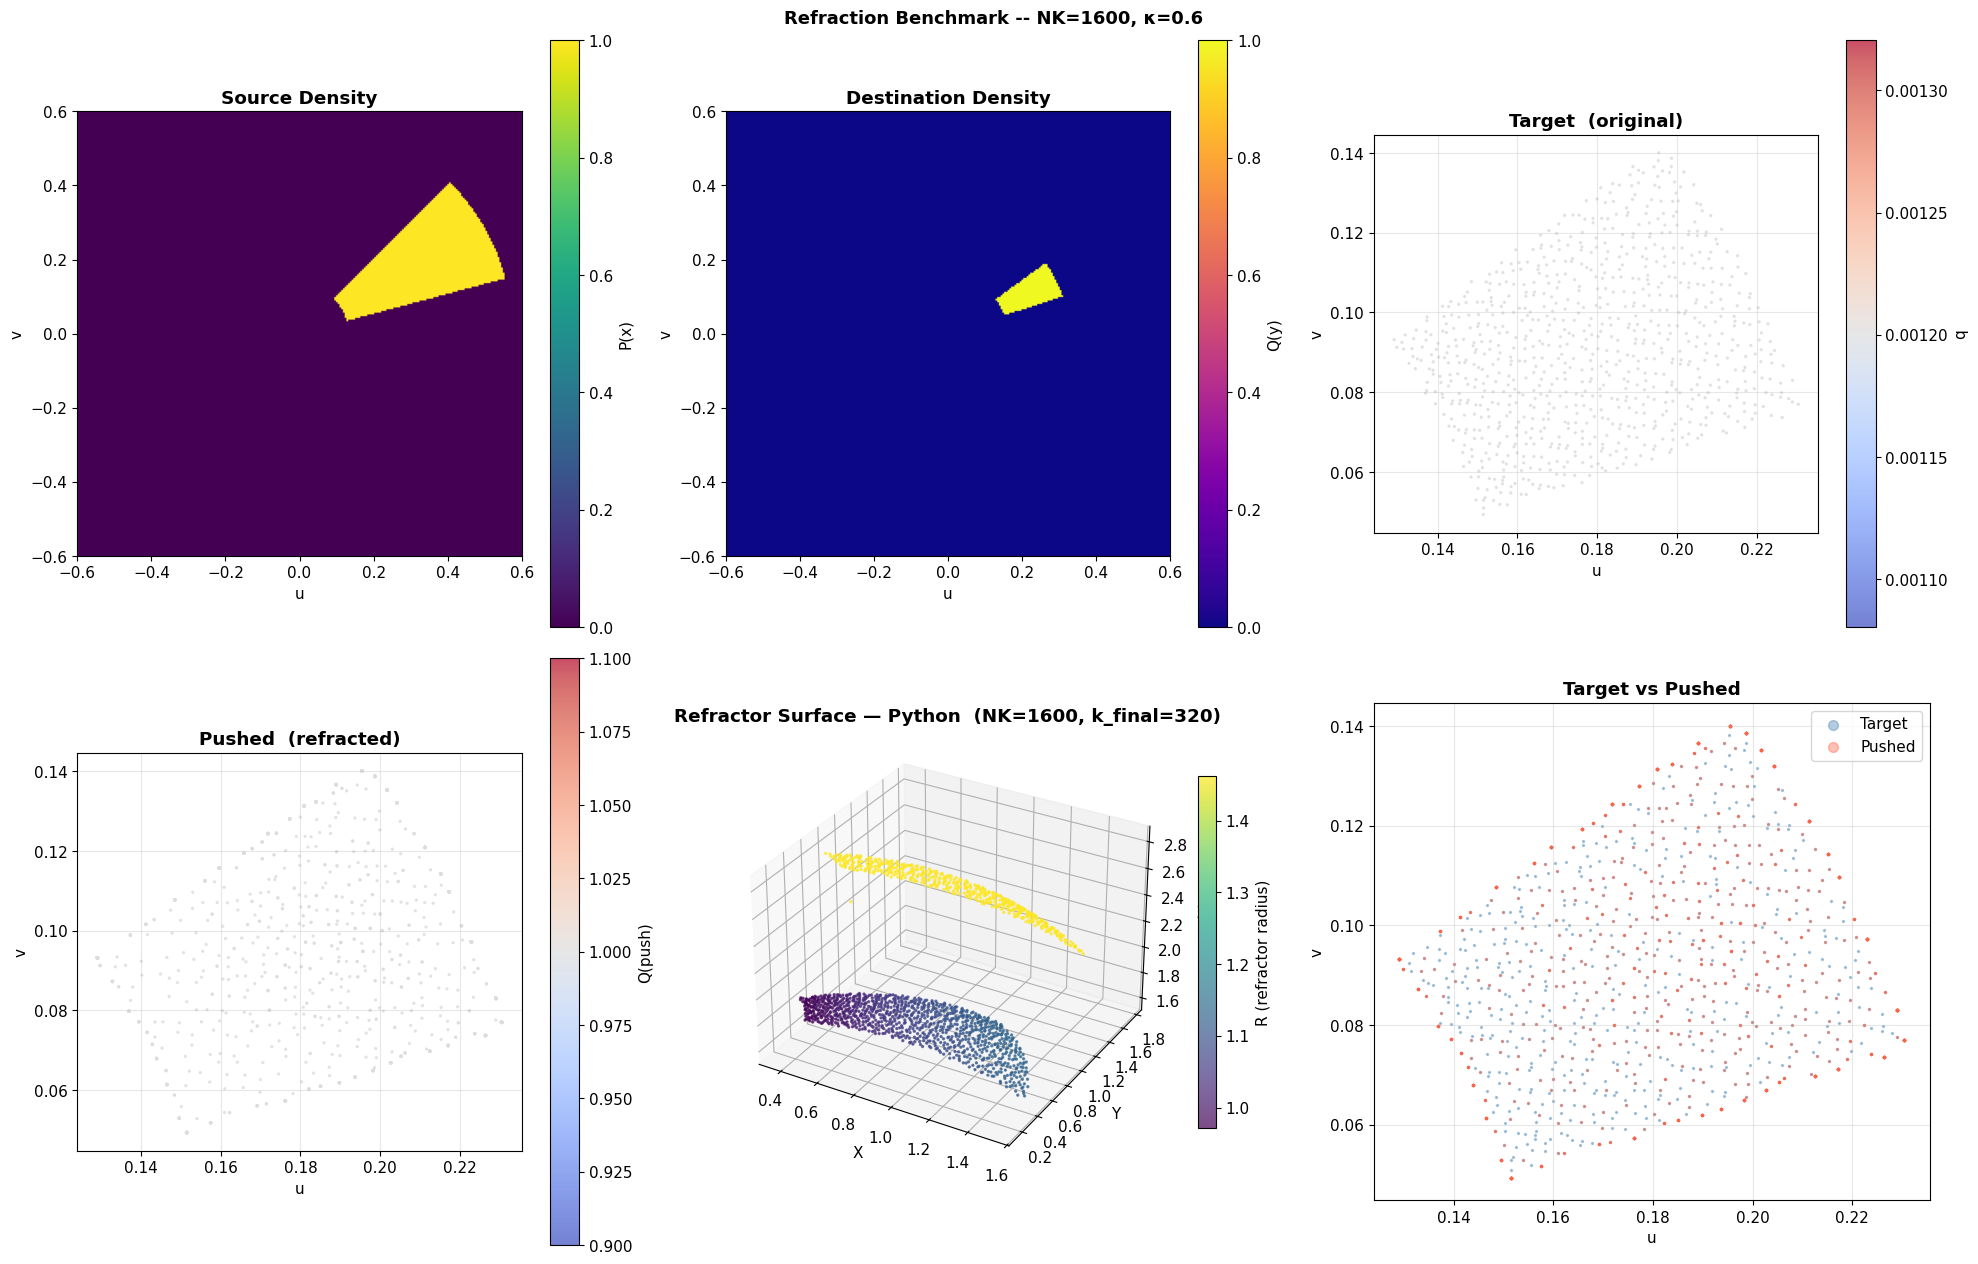

Saved fig_visualization.png


In [71]:
ext = [-0.6, 0.6, -0.6, 0.6]   # extent for imshow
k_final = 8 * int(np.floor(np.sqrt(NK)))

fig = plt.figure(figsize=(20, 13))
fig.suptitle(
    f'Refraction Benchmark -- NK={NK}, κ={kappa}',
    fontsize=13, fontweight='bold',
)

# ── Panel 1: Source Density (meshgrid imshow) ──────────────────────────────
ax = plt.subplot(2, 3, 1)
im = ax.imshow(X_MeshGrid.T, extent=ext, origin='lower', cmap='viridis', aspect='equal')
plt.colorbar(im, ax=ax, label='P(x)')
ax.set_title('Source Density', fontweight='bold')
ax.set_xlabel('u');  ax.set_ylabel('v')

# ── Panel 2: Destination Density (meshgrid imshow) ─────────────────────────
ax = plt.subplot(2, 3, 2)
im = ax.imshow(Y_MeshGrid.T, extent=ext, origin='lower', cmap='plasma', aspect='equal')
plt.colorbar(im, ax=ax, label='Q(y)')
ax.set_title('Destination Density', fontweight='bold')
ax.set_xlabel('u');  ax.set_ylabel('v')

# ── Panel 3: Target distribution (original scatter) ────────────────────────
ax = plt.subplot(2, 3, 3)
sc = ax.scatter(Y_projected[:, 0], Y_projected[:, 1], c=Y_projected[:, 2],
                cmap='coolwarm', s=2, alpha=0.7)
plt.colorbar(sc, ax=ax, label='q')
ax.set_title('Target  (original)', fontweight='bold')
ax.set_xlabel('u');  ax.set_ylabel('v')
ax.set_aspect('equal');  ax.grid(True, alpha=0.3)

# ── Panel 4: Pushed / refracted distribution ───────────────────────────────
ax = plt.subplot(2, 3, 4)
sc = ax.scatter(Y_Pushed_projected[:, 0], Y_Pushed_projected[:, 1],
                c=Y_Pushed_projected[:, 2], cmap='coolwarm', s=2, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Q(push)')
ax.set_title('Pushed  (refracted)', fontweight='bold')
ax.set_xlabel('u');  ax.set_ylabel('v')
ax.set_aspect('equal');  ax.grid(True, alpha=0.3)

# ── Panel 5: Refractor Surface (3D scatter, all NK points) ─────────────────
ax = plt.subplot(2, 3, 5, projection='3d')
sc5 = ax.scatter(Ref[:, 0], Ref[:, 1], Ref[:, 2],
                 s=2, alpha=0.7, c=R, cmap='viridis',
                 vmin=R.min(), vmax=R.max())
plt.colorbar(sc5, ax=ax, label='R (refractor radius)', shrink=0.6)
ax.set_title(f'Refractor Surface — Python  (NK={NK}, k_final={k_final})', fontweight='bold')
ax.set_xlabel('X');  ax.set_ylabel('Y');  ax.set_zlabel('Z')

# ── Panel 6: Target vs Pushed overlay ─────────────────────────────────────
ax = plt.subplot(2, 3, 6)
ax.scatter(Y_projected[:, 0],        Y_projected[:, 1],
           s=2, alpha=0.4, label='Target',  color='steelblue')
ax.scatter(Y_Pushed_projected[:, 0], Y_Pushed_projected[:, 1],
           s=2, alpha=0.4, label='Pushed', color='tomato')
ax.legend(markerscale=5);  ax.set_aspect('equal');  ax.grid(True, alpha=0.3)
ax.set_title('Target vs Pushed', fontweight='bold')
ax.set_xlabel('u');  ax.set_ylabel('v')

plt.tight_layout()
plt.savefig('fig_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_visualization.png')

## 6 — Radius Analysis

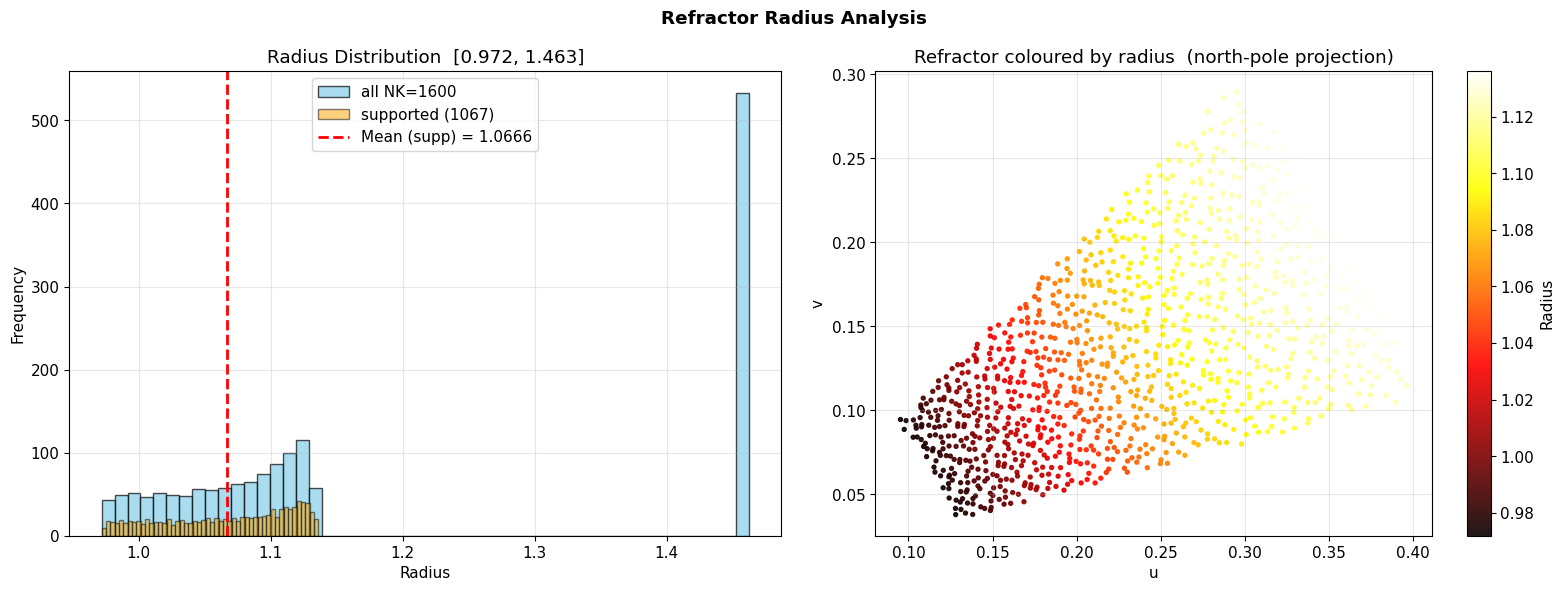

Saved fig_refractor_analysis.png


In [72]:
R_all  = R                 # all NK radii (including unsupported)
R_supp = R[mask_p]         # supported-only subset

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Refractor Radius Analysis', fontweight='bold')

# Histogram — all NK points to show full range [min_unsup, max_supp]
axes[0].hist(R_all, bins=50, edgecolor='black', alpha=0.7, color='skyblue', label=f'all NK={NK}')
axes[0].hist(R_supp, bins=50, edgecolor='black', alpha=0.5, color='orange', label=f'supported ({mask_p.sum()})')
axes[0].axvline(R_supp.mean(), color='red', ls='--', lw=2,
                label=f'Mean (supp) = {R_supp.mean():.4f}')
axes[0].legend()
axes[0].set_title(f'Radius Distribution  [{R_all.min():.3f}, {R_all.max():.3f}]')
axes[0].set_xlabel('Radius');  axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Scatter coloured by R (north-pole projection, supported only)
sc = axes[1].scatter(u_x[mask_p], v_x[mask_p], c=R_supp, cmap='hot', s=8, alpha=0.9)
plt.colorbar(sc, ax=axes[1], label='Radius')
axes[1].set_aspect('equal');  axes[1].grid(True, alpha=0.3)
axes[1].set_title('Refractor coloured by radius  (north-pole projection)')
axes[1].set_xlabel('u');  axes[1].set_ylabel('v')

plt.tight_layout()
plt.savefig('fig_refractor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_refractor_analysis.png')

## 7 — Interactive 3D Optical System  *(Plotly)*

Drag = rotate &emsp; Scroll = zoom &emsp; Hover = values  
Click legend items to toggle traces on/off.

In [73]:
import subprocess, importlib

try:
    import plotly.graph_objects as go
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'plotly', '--quiet'], check=True)
    importlib.invalidate_caches()
    import plotly.graph_objects as go

MAX_PTS = 6_000
rng     = np.random.default_rng(42)

fig3d = go.Figure()

# ── 1. Source hemisphere: scatter coloured by P(x) ──────────────────────────
src_idx = np.where(mask_p)[0]
si      = rng.choice(len(src_idx), min(len(src_idx), MAX_PTS), replace=False)
s_pts   = x[src_idx[si]];  s_col = p[src_idx[si]]
fig3d.add_trace(go.Scatter3d(
    x=s_pts[:, 0], y=s_pts[:, 1], z=s_pts[:, 2],
    mode='markers',
    marker=dict(size=2.5, color=s_col, colorscale='YlOrRd', opacity=0.65, showscale=False),
    name='Source  P(x)',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>P=%{marker.color:.4f}<extra></extra>',
))

# ── 2. Refractor surface: scatter coloured by radius ─────────────────────────
ref_idx = np.where(mask_p)[0]
ri      = rng.choice(len(ref_idx), min(len(ref_idx), MAX_PTS), replace=False)
ref_pts = Ref[ref_idx[ri]];  r_col = R[ref_idx[ri]]
fig3d.add_trace(go.Scatter3d(
    x=ref_pts[:, 0], y=ref_pts[:, 1], z=ref_pts[:, 2],
    mode='markers',
    marker=dict(size=3, color=r_col, colorscale='Viridis', opacity=0.85,
                showscale=True,
                colorbar=dict(title='Radius', x=1.02, len=0.55, y=0.5, thickness=15)),
    name='Refractor surface',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>R=%{marker.color:.4f}<extra></extra>',
))

# ── 3. Output light: push-forward on upper hemisphere ───────────────────────
n_push = len(y_push_3d)
pi     = rng.choice(n_push, min(n_push, MAX_PTS), replace=False)
push_col = Y_Pushed_projected[pi, 2]   # Q(y_pushed)
fig3d.add_trace(go.Scatter3d(
    x=y_push_3d[pi, 0], y=y_push_3d[pi, 1], z=y_push_3d[pi, 2],
    mode='markers',
    marker=dict(size=2.5, color=push_col, colorscale='Blues', opacity=0.65, showscale=False),
    name='Output light  Q(y)',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>Q=%{marker.color:.4f}<extra></extra>',
))

fig3d.update_layout(
    title=dict(
        text=(
            '<b>Optical System -- Refraction</b><br>'
            f'<sup>NK={NK}  \u00b7  \u03ba={kappa}  \u00b7  '
            'source P(x)  \u00b7  refractor (radius)  \u00b7  output Q(y)  \u00b7  '
            'drag=rotate  scroll=zoom  hover=values</sup>'
        ),
        x=0.5, xanchor='center',
    ),
    scene=dict(
        xaxis=dict(title='X', showgrid=True),
        yaxis=dict(title='Y', showgrid=True),
        zaxis=dict(title='Z', showgrid=True),
        aspectmode='data',
        camera=dict(eye=dict(x=1.4, y=1.4, z=0.8)),
    ),
    legend=dict(itemsizing='constant', x=0, y=1),
    margin=dict(l=0, r=80, t=100, b=0),
    width=960, height=720,
)

html_path = 'fig_optical_3d.html'
fig3d.write_html(html_path, include_plotlyjs='cdn')
from IPython.display import HTML, display as _display
_display(HTML(filename=html_path))
print(f'Interactive 3D plot saved to {html_path}')

Interactive 3D plot saved to fig_optical_3d.html


## 8 — Summary Statistics

In [74]:
k_final    = 8 * int(np.floor(np.sqrt(NK)))
total_cost = float(np.sum(p[mask_p]*f[mask_p]) + np.sum(q[mask_q]*g[mask_q]))

print('=' * 58)
print(f'  Benchmark      : Refraction (Figure 4)')
print(f'  Cost function  : c(x,y) = -log(1 - {kappa}*(x.y))')
print(f'  \u03ba              : {kappa}')
print(f'  NK             : {NK}')
print(f'  Source support : {mask_p.sum()} / {NK} points')
print(f'  Target support : {mask_q.sum()} / {NK} points')
print(f'  k_final        : {k_final}')
print(f'  Total cost     : {total_cost:.6e}')
print(f'  R range (all)  : [{R.min():.4f}, {R.max():.4f}]')
print(f'  R range (supp) : [{R[mask_p].min():.4f}, {R[mask_p].max():.4f}]')
print(f'  R mean (supp)  : {R[mask_p].mean():.4f}')
print(f'  max|f_raw-gc|  : {np.abs(f_raw[mask_p]-gc[mask_p]).max():.4e}')
print(f'  max|g_raw-fc|  : {np.abs(g_raw[mask_q]-fc[mask_q]).max():.4e}')
print(f'  Push-forward   : {len(y_push_3d)} source points mapped')
print('=' * 58)

  Benchmark      : Refraction (Figure 4)
  Cost function  : c(x,y) = -log(1 - 0.6*(x.y))
  κ              : 0.6
  NK             : 1600
  Source support : 1067 / 1600 points
  Target support : 833 / 1600 points
  k_final        : 320
  Total cost     : 1.479976e-01
  R range (all)  : [0.9719, 1.4625]
  R range (supp) : [0.9719, 1.1362]
  R mean (supp)  : 1.0666
  max|f_raw-gc|  : 8.9409e-03
  max|g_raw-fc|  : 8.9409e-03
  Push-forward   : 1067 source points mapped
